<a href="https://colab.research.google.com/github/Yennanng/PTDLNC/blob/develop/PTDLNC_B%C3%80I_NH%C3%93M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**BÀI 2: Bài tập Classification: Dự đoán khách hàng rời bỏ ngân hàng (Churn Prediction)**

**Bước 1: Khám phá dữ liệu (EDA)**

In [28]:
!pip install dmba

In [29]:
#load data
import gdown
url = "https://drive.google.com/uc?id=12dOGAhw3nZ104_OQsURmvW2M0Gj2iyM4"
data_filename = "churn.csv"
gdown.download(url, data_filename, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=12dOGAhw3nZ104_OQsURmvW2M0Gj2iyM4
To: /content/churn.csv
100%|██████████| 685k/685k [00:00<00:00, 47.2MB/s]


'churn.csv'

In [30]:
# Đọc dữ liệu
import pandas as pd
df = pd.read_csv("churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [31]:
# Mô tả số dòng, số cột
print("Kích thước dữ liệu (Dòng, Cột):", df.shape)

Kích thước dữ liệu (Dòng, Cột): (10000, 14)


In [32]:
#Tính tỷ lệ khách hàng rời đi (Exited=1) và ở lại (Exited=0)
churn_counts = df['Exited'].value_counts()
churn_percentage = df['Exited'].value_counts(normalize=True) * 100
print("\nSố lượng khách hàng theo nhóm:")
print(churn_counts)
print("\nTỷ lệ phần trăm (%):")
print(churn_percentage)


Số lượng khách hàng theo nhóm:
Exited
0    7963
1    2037
Name: count, dtype: int64

Tỷ lệ phần trăm (%):
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [33]:
# Bước 2. Tiền xử lý dữ liệu
# ---------------------------------------------------------

# 2.1. # Loại bỏ cột RowNumber, CustomerId, Surname vì không có giá trị dự báo
df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df_processed.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [34]:
from sklearn.preprocessing import LabelEncoder

# Loại bỏ cột định danh: RowNumber, CustomerId, Surname.

df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 1. Label Encoding cho Gender: Chuyển Female -> 0, Male -> 1
le = LabelEncoder()
df_processed['Gender'] = le.fit_transform(df_processed['Gender'])

# 2. One-Hot Encoding cho Geography: Chuyển sang 0 và 1 (dtype=int)
df_processed = pd.get_dummies(df_processed, columns=['Geography'], dtype=int)

# Hiển thị kết quả
df_processed.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [35]:
#Chuẩn hoá các biến số dùng StandardScaler

from sklearn.preprocessing import StandardScaler

# 1. Danh sách các biến số cần chuẩn hoá
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# 2. Khởi tạo công cụ StandardScaler
scaler = StandardScaler()

# 3. Tạo một bản sao dữ liệu mới để chuẩn hoá
# (Giữ lại df_processed gốc cho các mô hình dựa trên cây như Decision Tree/Random Forest)
df_logistic = df_processed.copy()

# 4. Thực hiện chuẩn hoá các cột số
df_logistic[num_cols] = scaler.fit_transform(df_logistic[num_cols])

# Hiển thị kết quả sau khi chuẩn hoá
df_logistic.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,-0.326221,0,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,1,1,0,0
1,-0.440036,0,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,0,0,0,1
2,-1.536794,0,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,1,1,0,0
3,0.501521,0,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,0,1,0,0
4,2.063884,0,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,0,0,0,1


In [36]:
# Chia dữ liệu thành train/test (80/20).
from sklearn.model_selection import train_test_split

# 1. Tách biến mục tiêu (y) - chung cho cả hai mô hình
y = df_processed['Exited']

# 2. Chia dữ liệu cho các mô hình dựa trên Cây (Decision Tree, Random Forest)
# Sử dụng df_processed (dữ liệu chưa chuẩn hóa)
X_tree = df_processed.drop('Exited', axis=1)
X_train_tree, X_test_tree, y_train, y_test = train_test_split(X_tree, y, test_size=0.2, random_state=42, stratify=y)

# 3. Chia dữ liệu cho mô hình Logistic Regression
# Sử dụng df_logistic (dữ liệu đã chuẩn hóa StandardScaler)
X_log = df_logistic.drop('Exited', axis=1)
X_train_log, X_test_log, _, _ = train_test_split(X_log, y, test_size=0.2, random_state=42, stratify=y)

# --- Kiểm tra kích thước và tỷ lệ ---
print("--- KÍCH THƯỚC DỮ LIỆU ---")
print(f"Kích thước tập Train: {X_train_tree.shape}")
print(f"Kích thước tập Test:  {X_test_tree.shape}")

print("\n--- TỶ LỆ KHÁCH HÀNG RỜI BỎ (EXITED = 1) ---")
train_rate = y_train.value_counts(normalize=True)[1] * 100
test_rate = y_test.value_counts(normalize=True)[1] * 100

print(f"Tỷ lệ trong tập Train: {train_rate:.2f}%")
print(f"Tỷ lệ trong tập Test:  {test_rate:.2f}%")

--- KÍCH THƯỚC DỮ LIỆU ---
Kích thước tập Train: (8000, 12)
Kích thước tập Test:  (2000, 12)

--- TỶ LỆ KHÁCH HÀNG RỜI BỎ (EXITED = 1) ---
Tỷ lệ trong tập Train: 20.38%
Tỷ lệ trong tập Test:  20.35%


**Bước 3: Logistic Regression**

In [37]:
# 3.1. Huấn luyện Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

# Huấn luyện mô hình trên tập Train
logistic_model.fit(X_train_log, y_train)

print("Logistic Regression hoàn tất!")


Logistic Regression hoàn tất!


In [38]:
# 3.2. Phân tích hệ số hồi quy, yếu tố nào làm tăng khả năng khách hàng rời đi?
import pandas as pd

# intercept (hệ số chặn)
print("Intercept:", logistic_model.intercept_[0])

# bảng hệ số hồi quy
print(
    pd.DataFrame(
        {'coeff': logistic_model.coef_[0]}, index=X_log.columns).transpose())

Intercept: -0.5340885053088992
       CreditScore    Gender       Age    Tenure   Balance  NumOfProducts  \
coeff    -0.085978 -0.522362  0.735166 -0.019938  0.160682      -0.070447   

       HasCrCard  IsActiveMember  EstimatedSalary  Geography_France  \
coeff   -0.07056        -1.02809          0.04795         -0.462747   

       Geography_Germany  Geography_Spain  
coeff           0.358006        -0.418342  


In [39]:
# 3.3. Kết quả Confusion Matrix và ROC Curve.
# Dự đoán nhãn (0/1) trên tập train
y_pred_train = logistic_model.predict(X_train_log)

# Dự đoán xác suất trên tập train
y_prob_train = logistic_model.predict_proba(X_train_log)

#Tạo bảng p(0), p(1), predicted
import pandas as pd

logit_result_train = pd.DataFrame({
    'actual': y_train,
    'p(0)': y_prob_train[:, 0],
    'p(1)': y_prob_train[:, 1],
    'predicted': y_pred_train
})

logit_result_train.head()



,actual,p(0),p(1),predicted
2151,1,0.624938,0.375062,0
8392,1,0.771871,0.228129,0
5006,0,0.804402,0.195598,0
4117,0,0.871333,0.128667,0
7182,0,0.736293,0.263707,0


In [47]:
# Một vài trường hợp để phân tích
interesting_cases = logit_result_train.sample(5, random_state=42)
print(interesting_cases)

      actual      p(0)      p(1)  predicted
2464       0  0.830659  0.169341          0
3873       0  0.942342  0.057658          0
9079       0  0.942213  0.057787          0
654        0  0.957869  0.042131          0
4320       0  0.724379  0.275621          0


In [41]:
# Confusion Matrix
from dmba import classificationSummary
# trên tập train
classificationSummary(y_train, logistic_model.predict(X_train_log))

# trên tập test
classificationSummary(y_test, logistic_model.predict(X_test_log))


Confusion Matrix (Accuracy 0.8106)

       Prediction
Actual    0    1
     0 6136  234
     1 1281  349
Confusion Matrix (Accuracy 0.8080)

       Prediction
Actual    0    1
     0 1540   53
     1  331   76


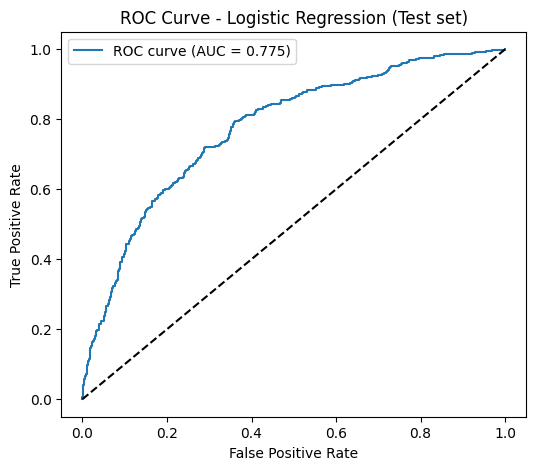

In [42]:
# ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Lấy xác suất class = 1 trên tập test
y_test_proba = logistic_model.predict_proba(X_test_log)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# AUC
auc_score = roc_auc_score(y_test, y_test_proba)

# Vẽ ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (Test set)')
plt.legend()
plt.show()


In [48]:
# 3.4. Kết quả  trên test set: Accuracy, Precision, Recall, F1-score, ROC-AUC.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Dự đoán nhãn (0/1) trên tập test
y_pred_test = logistic_model.predict(X_test_log)

# Dự đoán xác suất trên tập test (lấy xác suất class = 1)
y_prob_test = logistic_model.predict_proba(X_test_log)[:, 1]

# Tính các chỉ số đánh giá
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_prob_test)

# In kết quả
print("Kết quả đánh giá trên tập test:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# (Tùy chọn) In bảng classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Kết quả đánh giá trên tập test:
Accuracy  : 0.8080
Precision : 0.5891
Recall    : 0.1867
F1-score  : 0.2836
ROC-AUC   : 0.7748

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

